# Reproduce F1 vs. instance count / signer count correlation figures

Regenerates `corr_mat_MViTv2_S.pdf` (F1 vs. training instance count) and
`corr_signers_MViTv2_S.pdf` (F1 vs. training signer count) for a given
WLASL split and model, using:

1. A results JSON with `cls_rep`, `all_targets`, `all_preds` keys
   (e.g. `src/runs/asl2000/MViTv2_S_e/exp002/results/cls_rep_all_targets_preds.json`)
2. Per-class training-set stats (instance counts, signer distributions),
   loaded the same way as in your original stats notebook.

**Assumptions to verify** (see markdown notes inline below):
- `cls_rep` keys map to glosses via `get_class_list()` ordering when numeric.
- Instance/signer counts are drawn from the **training** set, not test/val.
- Signer count = number of unique signer IDs (dict keys), not total occurrences.
- Point shading = number of classes sharing an exact (x, F1) coordinate.

In [26]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# locals -- same package used in your original stats notebook
from src.configs import get_class_list
from src.preprocess import WLASLClass
from src.run_types import RUNS_PATH
from src.stats import (
    AVAIL_SETS,
    AVAIL_SPLITS,
    get_per_instance_stats,
    reverse_preproc_format,
)
from src.video_dataset import (
    get_labels_path,
    get_wlasl_info,
    load_data_from_json,
)

sns.set_style(
    "darkgrid"
)  # matches the light purple-grey background in the original figures

## Parameters

Adjust `split_name`, `model_name`, and `results_path` for whichever run you want to plot.

In [27]:
verbosity = 1
def printv(*args, level=1, **kwargs):
    if level <= verbosity:
        print(*args, **kwargs)

split_name: AVAIL_SPLITS = "asl2000"  # change for a different split
model_name = "MViTv2_S"
exp_name = "exp002"  # change if your run used a different experiment id

results_path = RUNS_PATH / f"{split_name}/{model_name}/{exp_name}/results/cls_rep_all_targets_preds.json"
# tp_path = RUNS_PATH / 'asl2000/MViTv2_B_32x3/exp004/results/all_targets_preds.json'
# cls_rep_path = RUNS_PATH / 'asl2000/MViTv2_B_32x3/exp004/results/topk_cls_report.json'


output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

classes = get_class_list()
printv(f"Num classes: {len(classes)}")

Num classes: 2000


## Load classification results and extract per-class F1

We read per-class F1 straight from `cls_rep`, since that's presumably the
same dict used to report your accuracy figures elsewhere in the paper --
safer than recomputing from `all_targets`/`all_preds`, which risks a
label-ordering mismatch if you don't have the exact label encoding used
at training/eval time.

In [28]:
with open(results_path) as f:
    results = {k : v for k, v in json.load(f).items()}
    
# with open(tp_path, 'r') as f:
#     tp_d = json.load(f)
    
# with open(cls_rep_path, 'r') as f:
#     cls_rep_d = json.load(f)
    
# results = {k : v for k, v in tp_d.items()} | {k : v for k, v in cls_rep_d.items()}

print(results.keys())

dict_keys(['cls_report', 'all_targets', 'all_preds'])


In [29]:


cls_rep = results["cls_report"]
all_targets = results["all_targets"]
all_preds = results["all_preds"]

exclude_keys = {"accuracy", "macro avg", "weighted avg"}

per_class_rows = []
for key, metrics_dict in cls_rep.items():
    if key in exclude_keys:
        continue
    # cls_rep keys are either stringified numeric labels (map via classes list)
    # or already gloss strings -- handle both
    if key.isdigit():
        gloss = classes[int(key)]
    else:
        gloss = key
    per_class_rows.append({"gloss": gloss, "f1": metrics_dict["f1-score"]})

f1_df = pd.DataFrame(per_class_rows)
printv(f"Loaded F1 scores for {len(f1_df)} classes")
f1_df.head()

Loaded F1 scores for 2000 classes


,gloss,f1
0,book,0.600000
1,drink,0.666667
2,computer,0.750000
3,before,0.000000
4,chair,0.666667


## Load per-class training-set instance and signer counts

Uses the same loading path as your original stats notebook, but only for
the `train` set, since the original figures plot F1 (test set) against
*training* supervision available per class.

In [30]:
set_name: AVAIL_SETS = "train"

set_path_info = get_wlasl_info(split_name, set_name)
set_path = get_labels_path(set_name, set_path_info["labels"], set_path_info["label_suff"])
train_data = reverse_preproc_format(load_data_from_json(set_path, policy="strict"), classes)

train_stats = get_per_instance_stats([WLASLClass.model_validate(i) for i in train_data])

stats_rows = []
for gloss, stat in train_stats.items():
    num_instances = stat["num_instances"]
    signers_distribution = stat["signers_distribution"]  # {signer_id: occurrence_count}
    num_signers = len(signers_distribution)  # unique signer count
    stats_rows.append({"gloss": gloss, "num_instances": num_instances, "num_signers": num_signers})

stats_df = pd.DataFrame(stats_rows)
printv(f"Loaded stats for {len(stats_df)} classes")
stats_df.head()

Loaded stats for 2000 classes


,gloss,num_instances,num_signers
0,book,30,14
1,drink,25,15
2,computer,20,12
3,before,18,13
4,chair,19,11


In [31]:
merged = f1_df.merge(stats_df, on="gloss", how="inner")

if len(merged) != len(f1_df):
    missing = set(f1_df["gloss"]) - set(merged["gloss"])
    print(f"WARNING: {len(missing)} glosses from results not found in training stats: {missing}")

merged.head()

,gloss,f1,num_instances,num_signers
0,book,0.600000,30,14
1,drink,0.666667,25,15
2,computer,0.750000,20,12
3,before,0.000000,18,13
4,chair,0.666667,19,11


## Plotting function

Reused for both the instance-count and signer-count figures. Point shading
reflects how many classes share the exact same `(x, F1)` coordinate --
adjust `vmin`/`cmap` below if your original used a different scheme.

In [32]:
def plot_f1_correlation(df, x_col, x_label, title, save_path=None):
    x = df[x_col].values
    y = df["f1"].values

    tau, p_value = stats.kendalltau(x, y)

    # Count how many rows share the exact (x, f1) pair, for shading
    coord_counts = df.groupby([x_col, "f1"])[x_col].transform("size").values

    fig, ax = plt.subplots(figsize=(9, 6))
    norm_counts = coord_counts / coord_counts.max()
    norm_counts = 0.4 + 0.6 * norm_counts  # remap to [0.4, 1.0] instead of [0, 1.0]

    ax.scatter(
        x, y,
        c=norm_counts,
        cmap="Blues",
        vmin=0, vmax=1,
        s=70,
        edgecolors="none",
    )

    # Linear fit line -- illustrates trend direction only, not a bounded
    # predictive model (F1 is bounded in [0, 1])
    coeffs = np.polyfit(x, y, deg=1)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = np.polyval(coeffs, x_line)
    ax.plot(
        x_line, y_line, color="red",
        label=f"Linear fit (Kendall $\\tau$ = {tau:.3f}, p = {p_value:.3e})",
    )

    ax.set_xlabel(x_label)
    ax.set_ylabel("F1 score")
    ax.set_title(title)
    ax.legend(loc="upper left")

    if save_path:
        fig.savefig(save_path, bbox_inches="tight")
        printv(f"Saved to {save_path}")

    return fig, ax, tau, p_value

## Figure 1: F1 vs. instance count

Saved to outputs/corr_mat_MViTv2_S.pdf
Instance count correlation: tau=0.188, p=3.441e-25


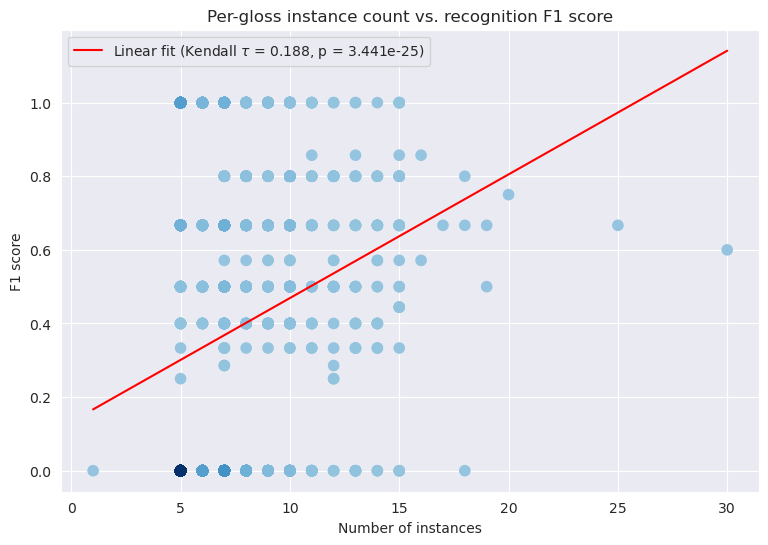

In [33]:
fig1, ax1, tau_inst, p_inst = plot_f1_correlation(
    merged,
    x_col="num_instances",
    x_label="Number of instances",
    title="Per-gloss instance count vs. recognition F1 score",
    save_path=output_dir / f"corr_mat_{model_name}.pdf",
)
print(f"Instance count correlation: tau={tau_inst:.3f}, p={p_inst:.3e}")

## Figure 2: F1 vs. signer count

Saved to outputs/corr_signers_MViTv2_S.pdf
Signer count correlation: tau=0.201, p=5.020e-29


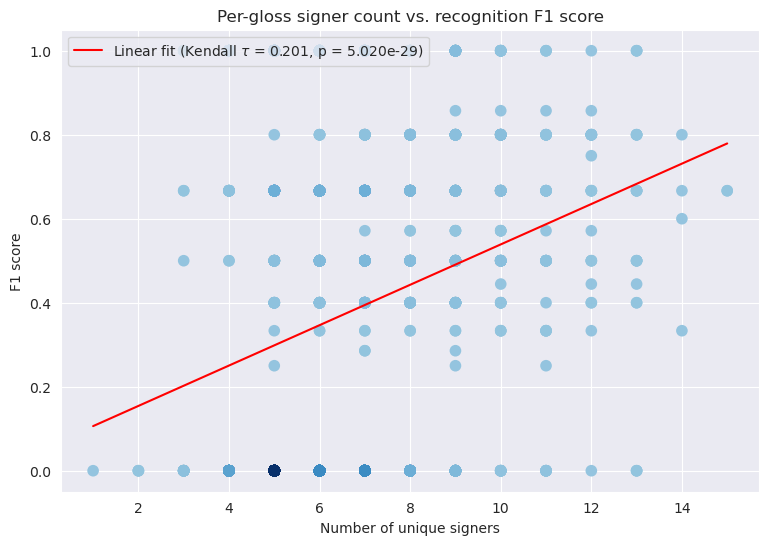

In [34]:
fig2, ax2, tau_signers, p_signers = plot_f1_correlation(
    merged,
    x_col="num_signers",
    x_label="Number of unique signers",
    title="Per-gloss signer count vs. recognition F1 score",
    save_path=output_dir / f"corr_signers_{model_name}.pdf",
)
print(f"Signer count correlation: tau={tau_signers:.3f}, p={p_signers:.3e}")

In [37]:
print(list(cls_rep.keys())[:10])
print(classes[:10])
print(f"cls_rep classes: {len(f1_df)}")
print(f"train_stats classes: {len(stats_df)}")
print(f"merged: {len(merged)}")
print(f1_df["gloss"].duplicated().sum())
print(stats_df["gloss"].duplicated().sum())
print(merged["num_instances"].describe())
print(merged["num_signers"].describe())
sample = merged.sample(5, random_state=0)
print(sample)

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
['book', 'drink', 'computer', 'before', 'chair', 'go', 'clothes', 'who', 'candy', 'cousin']
cls_rep classes: 2000
train_stats classes: 2000
merged: 2000
0
0
count    2000.000000
mean        7.145000
std         2.539724
min         1.000000
25%         5.000000
50%         7.000000
75%         8.000000
max        30.000000
Name: num_instances, dtype: float64
count    2000.000000
mean        6.552000
std         2.001324
min         1.000000
25%         5.000000
50%         6.000000
75%         8.000000
max        15.000000
Name: num_signers, dtype: float64
         gloss        f1  num_instances  num_signers
405       idea  0.666667              9            9
1190  positive  0.000000              6            6
1132    heaven  1.000000              6            6
731       much  0.400000              7            7
1754    former  0.666667              5            5


In [38]:
# If cls_rep key "0" maps to gloss classes[0], then the most frequent
# integer in all_targets should correspond to a gloss with high support
# in cls_rep's "support" field for that same key
from collections import Counter
target_counts = Counter(all_targets)
top_label, top_count = target_counts.most_common(1)[0]
print(f"Most frequent target label: {top_label} (n={top_count})")
print(f"cls_rep support for that label: {cls_rep[str(top_label)]['support']}")

Most frequent target label: 2 (n=5)
cls_rep support for that label: 5.0


In [39]:
# Total test instances vs. total test classes
test_path_info = get_wlasl_info(split_name, "test")
test_path = get_labels_path("test", test_path_info["labels"], test_path_info["label_suff"])
test_data = reverse_preproc_format(load_data_from_json(test_path, policy="strict"), classes)
test_stats = get_per_instance_stats([WLASLClass.model_validate(i) for i in test_data])

total_test_instances = sum(s["num_instances"] for s in test_stats.values())
print(f"Total test classes: {len(test_stats)}")
print(f"Total test instances: {total_test_instances}")


Total test classes: 2000
Total test instances: 2879


In [40]:
# Build an instance-level dataframe: one row per test instance, using
# that instance's correctness (not its class's F1) as the outcome,
# with per-class instance/signer counts repeated across rows.

# Requires per-instance correctness -- do you have this alongside
# all_targets/all_preds? e.g.:
correct = [int(t == p) for t, p in zip(all_targets, all_preds)]

# Map each instance's target label -> gloss -> num_instances/num_signers
gloss_lookup = merged.set_index("gloss")[["num_instances", "num_signers"]]

instance_rows = []
for target, is_correct in zip(all_targets, correct):
    gloss = classes[int(target)] if str(target).isdigit() else target
    if gloss in gloss_lookup.index:
        row = gloss_lookup.loc[gloss]
        instance_rows.append({
            "gloss": gloss,
            "correct": is_correct,
            "num_instances": row["num_instances"],
            "num_signers": row["num_signers"],
        })

instance_df = pd.DataFrame(instance_rows)
print(f"Instance-level rows: {len(instance_df)}")

tau_inst_level, p_inst_level = stats.kendalltau(instance_df["num_instances"], instance_df["correct"])
print(f"Per-instance tau={tau_inst_level:.3f}, p={p_inst_level:.3e}")

Instance-level rows: 2879
Per-instance tau=0.142, p=2.208e-18
